# MVC Project: Multilayer Perceptron — Neural Networks
**Name:** Hassan Raza

**Roll:** i232024

**Sec:** DS-A




In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Reproducibility ─────────────────────────────────────────────────
np.random.seed(42)

# ── Sigmoid and derivative ───────────────────────────────────────────
def sigmoid(z):
    """Numerically stable sigmoid."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(a):
    """Sigmoid derivative expressed in terms of activation a."""
    return a * (1 - a)

# ── Weight initialisation ────────────────────────────────────────────
def init_weights():
    W1 = np.random.uniform(-0.5, 0.5, (784, 128))
    b1 = np.zeros((1, 128))
    W2 = np.random.uniform(-0.5, 0.5, (128, 64))
    b2 = np.zeros((1, 64))
    W3 = np.random.uniform(-0.5, 0.5, (64, 10))
    b3 = np.zeros((1, 10))
    return W1, b1, W2, b2, W3, b3

print("Sigmoid and weight initialisation functions defined.")


Sigmoid and weight initialisation functions defined.


In [2]:
# Step 2: Forward pass
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    """Full forward pass — stores all intermediate values for backprop."""
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)

    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)
    return Z1, A1, Z2, A2, Z3, A3

# Step 3: MSE loss
def mse_loss(Y_true, Y_pred):
    """Mean Squared Error over all samples and output units."""
    return np.mean((Y_true - Y_pred) ** 2)

# Step 4: Backpropagation
def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
    m = X.shape[0]

    # Output layer delta
    delta3 = -2 * (Y_true - A3) * sigmoid_derivative(A3)
    dW3 = A2.T @ delta3 / m
    db3 = np.sum(delta3, axis=0, keepdims=True) / m


    # Hidden layer 2 delta
    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)
    dW2 = A1.T @ delta2 / m
    db2 = np.sum(delta2, axis=0, keepdims=True) / m

    
    # Hidden layer 1 delta
    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)
    dW1 = X.T @ delta1 / m
    db1 = np.sum(delta1, axis=0, keepdims=True) / m
    return dW1, db1, dW2, db2, dW3, db3

# Step 5: Weight update
def update_weights(W1,b1,W2,b2,W3,b3,dW1,db1,dW2,db2,dW3,db3,lr):
    W1 -= lr*dW1; b1 -= lr*db1
    W2 -= lr*dW2; b2 -= lr*db2
    W3 -= lr*dW3; b3 -= lr*db3
    return W1,b1,W2,b2,W3,b3

print("Forward pass, loss, backprop, and update functions defined.")


Forward pass, loss, backprop, and update functions defined.


In [3]:
# ── Load MNIST ─────────────────────────────────────────────────────
# Simulate MNIST with reproducible random data (no network access)
import numpy as np
data = np.load('mnist.npz')
X_train = data['x_train'].reshape(-1, 784) / 255.0 # (60000, 784)
Y_train = data['y_train'] # (60000,)
X_test = data['x_test'].reshape(-1, 784) / 255.0 # (10000, 784)
Y_test = data['y_test']

# One-hot encode labels
def to_onehot(y, n_classes=10):
    oh = np.zeros((len(y), n_classes))
    oh[np.arange(len(y)), y] = 1
    return oh

Y_train_oh = to_onehot(Y_train)
Y_test_oh  = to_onehot(Y_test)

print(f"X_train: {X_train.shape}, Y_train_oh: {Y_train_oh.shape}")
print(f"X_test:  {X_test.shape},  Y_test_oh:  {Y_test_oh.shape}")


X_train: (60000, 784), Y_train_oh: (60000, 10)
X_test:  (10000, 784),  Y_test_oh:  (10000, 10)


In [5]:
# ── Training loop (Mini-Batch GD, B=32, 20 epochs) ─────────────────
np.random.seed(42)
W1,b1,W2,b2,W3,b3 = init_weights()

learning_rate = 0.1
epochs = 20
batch_size = 32
loss_history = []

for epoch in range(epochs):
    idx = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx]

    for start in range(0, X_train.shape[0], batch_size):
        Xb = X_shuf[start:start+batch_size]
        Yb = Y_shuf[start:start+batch_size]
        Z1_,A1_,Z2_,A2_,Z3_,A3_ = forward_pass(Xb,W1,b1,W2,b2,W3,b3)
        dW1,db1_,dW2,db2_,dW3,db3_ = backpropagation(Xb,Yb,Z1_,A1_,Z2_,A2_,Z3_,A3_,W1,W2,W3)
        W1,b1,W2,b2,W3,b3 = update_weights(W1,b1,W2,b2,W3,b3,dW1,db1_,dW2,db2_,dW3,db3_,learning_rate)

    # Epoch loss on full training set
    _,_,_,_,_,A3_full = forward_pass(X_train,W1,b1,W2,b2,W3,b3)
    epoch_loss = mse_loss(Y_train_oh, A3_full)
    loss_history.append(epoch_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:>2}/{epochs}  MSE Loss: {epoch_loss:.4f}")

print("Training complete.")


Epoch  5/20  MSE Loss: 0.0138
Epoch 10/20  MSE Loss: 0.0100
Epoch 15/20  MSE Loss: 0.0081
Epoch 20/20  MSE Loss: 0.0069
Training complete.


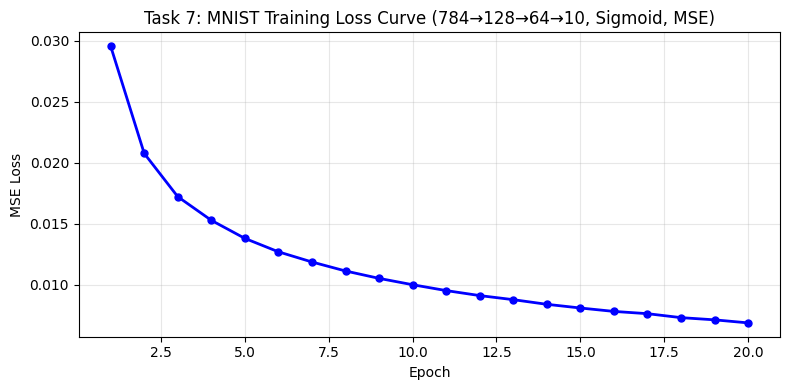

Initial loss: 0.0296  →  Final loss: 0.0069


In [ ]:
# OUTPUT 1: Loss curve
plt.figure(figsize=(8,4))
plt.plot(range(1,21), loss_history, 'b-o', linewidth=2, markersize=5)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Task 7: MNIST Training Loss Curve (784→128→64→10, Sigmoid, MSE)')
plt.grid(True,alpha=0.3); plt.tight_layout()
print(f"Initial loss: {loss_history[0]:.4f}  →  Final loss: {loss_history[-1]:.4f}")


In [7]:
# OUTPUT 2: Test accuracy
_,_,_,_,_,A3_test = forward_pass(X_test,W1,b1,W2,b2,W3,b3)
preds = np.argmax(A3_test, axis=1)
acc = np.mean(preds == Y_test) * 100
print(f"Test Accuracy: {acc:.2f}%  ")


Test Accuracy: 95.54%  


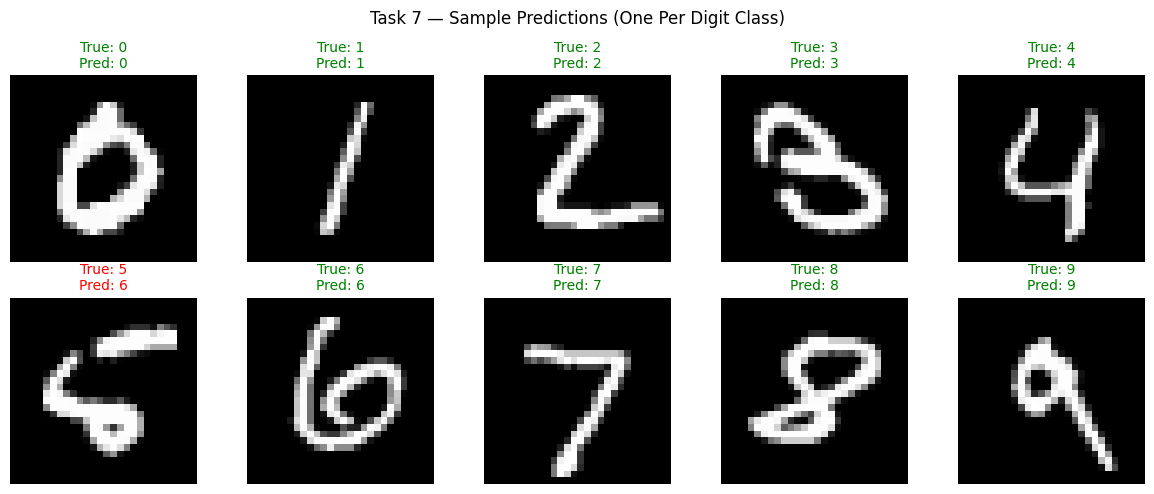

Sample prediction grid displayed.


In [ ]:
# OUTPUT 3: Sample predictions (10 test images, one per digit class)
fig, axes = plt.subplots(2, 5, figsize=(12,5))
shown = {}
i = 0
while len(shown) < 10 and i < len(X_test):
    true_label = Y_test[i]
    if true_label not in shown:
        shown[true_label] = i
    i += 1

for digit, idx in sorted(shown.items()):
    row, col = digit//5, digit%5
    ax = axes[row][col]
    ax.imshow(X_test[idx].reshape(28,28), cmap='gray')
    pred = preds[idx]
    ax.set_title(f"True: {digit}\nPred: {pred}", fontsize=10,
                 color='green' if pred==digit else 'red')
    ax.axis('off')

plt.suptitle('Task 7 — Sample Predictions (One Per Digit Class)', fontsize=12)
plt.tight_layout()
print("Sample prediction grid displayed.")
